<a href="https://colab.research.google.com/github/mariyacode/project1/blob/main/finance_ipnyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (3).zip


In [56]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [57]:
import os
os.listdir()

['.config',
 'archive (2).zip',
 'archive.zip',
 'budgetwise_finance_dataset.csv',
 'budgetwise_synthetic_dirty.csv',
 'archive (1).zip',
 'clean_budgetwise_dataset.csv',
 'archive (3).zip',
 'sample_data']

In [58]:
import pandas as pd

In [59]:
df = pd.read_csv("budgetwise_finance_dataset.csv")

In [60]:
df.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T4999,U018,2023-04-25,Expense,Educaton,3888,card,Ahmedabad,Movie tickets
1,T12828,U133,08/05/2022,Expense,rent,649,NaN,Hyderabad,asdfgh
2,T7403,U091,31-12-23,Income,Freelance,13239,Csh,BAN,Books
3,T12350,U097,NaN,Expense,Fod,6299,Bank Transfer,AHMEDABAD,Electricity bill
4,T7495,U088,10/28/2022,Expense,entertainment,2287,CARD,Hyderabad,NaN


In [61]:
df.shape

(15900, 9)

In [62]:
df.columns

Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'amount', 'payment_mode', 'location', 'notes'],
      dtype='object')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    15900 non-null  object
 1   user_id           15900 non-null  object
 2   date              15414 non-null  object
 3   transaction_type  15900 non-null  object
 4   category          15615 non-null  object
 5   amount            15609 non-null  object
 6   payment_mode      15092 non-null  object
 7   location          14638 non-null  object
 8   notes             13079 non-null  object
dtypes: object(9)
memory usage: 1.1+ MB


In [64]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
date,486
transaction_type,0
category,285
amount,291
payment_mode,808
location,1262
notes,2821


In [65]:
df["category"].unique()

array(['Educaton', 'rent', 'Freelance', 'Fod', 'entertainment', 'Foods',
       'education', 'Salary', 'Utilties', 'Others', 'Utility', 'Utlities',
       'Rentt', 'Food', 'FOOD', 'Travel', 'food', 'health',
       'Entertainment', 'Travl', 'Investment', 'Foodd', 'HEALTH', 'RENT',
       'Helth', 'Education', 'utilities', 'Rent', 'Rnt', 'savings', 'EDU',
       'Traval', nan, 'Bonus', 'travel', 'Utilities', 'Entertain',
       'Saving', 'Entrtnmnt', 'TRAVEL', 'SAVINGS', 'Misc', 'others',
       'Health', 'Other', 'Savings', 'OTHERS'], dtype=object)

In [66]:
df["payment_mode"].unique()

array(['card', nan, 'Csh', 'Bank Transfer', 'CARD', 'Crd', 'CRD', 'upi',
       'UPI', 'bank transfer', 'UPi', 'BankTransfer', 'Bank_Transfer',
       'Card', 'Bank Transfr', 'csh', 'Cash', 'Upi', 'cash', 'CASH'],
      dtype=object)

In [67]:
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

In [68]:
df["amount"].describe()

,amount
count,1.244000e+04
mean,5.085903e+06
std,7.098490e+07
min,-1.000000e+03
25%,2.855000e+03
50%,5.947000e+03
75%,9.561750e+03
max,1.000000e+09


In [69]:
df.duplicated().sum()

np.int64(900)

In [70]:
df = df.drop_duplicates()

In [71]:
df.duplicated().sum()

np.int64(0)

In [29]:
df["category"] = df["category"].str.lower()

/tmp/ipykernel_339/614802269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["category"] = df["category"].str.lower()


In [72]:
df.loc[:, "category"] = df["category"].str.lower()

In [31]:
df["payment_mode"] = df["payment_mode"].str.lower()

/tmp/ipykernel_339/3413049845.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["payment_mode"] = df["payment_mode"].str.lower()


In [73]:
df.loc[:, "payment_mode"] = df["payment_mode"].str.lower()

In [74]:
df = df[df["amount"] > 0]

In [75]:
df = df[df["amount"] < 100000]

In [76]:
df["category"].unique()

array(['educaton', 'rent', 'freelance', 'fod', 'entertainment', 'foods',
       'salary', 'others', 'utlities', 'rentt', 'food', 'health', 'travl',
       'education', 'investment', 'foodd', 'travel', 'helth', 'utilities',
       'rnt', 'savings', 'edu', 'traval', nan, 'bonus', 'utility',
       'entertain', 'utilties', 'saving', 'entrtnmnt', 'misc', 'other'],
      dtype=object)

In [77]:
df["category"] = df["category"].replace({
    "fod": "food",
    "foods": "food",
    "foodd": "food",
    "rentt": "rent",
    "rnt": "rent",
    "travl": "travel",
    "traval": "travel",
    "helth": "health",
    "entertain": "entertainment",
    "entrtnmnt": "entertainment"

})

In [78]:
df["category"].value_counts()

,count
category,
food,2420
rent,1929
travel,1426
entertainment,959
health,453
others,442
utilities,438
education,388
freelance,337


In [79]:
df["payment_mode"] = df["payment_mode"].replace({
    "csh": "cash",
    "crd": "card",
    "bank transfr": "bank_transfer",
    "banktransfer": "bank_transfer",
    "bank transfer": "bank_transfer"
})

In [80]:
df["payment_mode"].value_counts()

,count
payment_mode,
card,2742
cash,2720
bank_transfer,2719
upi,2605


In [81]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [82]:
df["date"].head()

,date
0,2023-04-25
1,NaT
2,NaT
3,NaT
4,NaT


In [83]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
date,7013
transaction_type,0
category,194
amount,0
payment_mode,549
location,884
notes,1976


In [84]:
df["category"] = df["category"].fillna("others")
df["payment_mode"] = df["payment_mode"].fillna("unknown")

In [85]:
df.to_csv("clean_budgetwise_dataset.csv", index=False)

In [86]:
df["category"].value_counts()

,count
category,
food,2420
rent,1929
travel,1426
entertainment,959
others,636
health,453
utilities,438
education,388
freelance,337


In [87]:
df["payment_mode"].value_counts()

,count
payment_mode,
card,2742
cash,2720
bank_transfer,2719
upi,2605
unknown,549


In [88]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
date,7013
transaction_type,0
category,0
amount,0
payment_mode,0
location,884
notes,1976


In [89]:
df["category"] = df["category"].replace({
    "utility": "utilities",
    "utlities": "utilities",
    "edu": "education",
    "educationn": "education",
    "foodd": "food"
})

In [90]:
df["category"].value_counts()

,count
category,
food,2420
rent,1929
travel,1426
entertainment,959
utilities,909
others,636
education,562
health,453
freelance,337


In [91]:
df = df.dropna(subset=["date"])

In [92]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
date,0
transaction_type,0
category,0
amount,0
payment_mode,0
location,363
notes,768


In [106]:
df["location"] = df["location"].fillna("Hyderabad")

In [107]:
df["notes"] = df["notes"].fillna("no_note")

In [108]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
date,0
transaction_type,0
category,0
amount,0
payment_mode,0
location,0
notes,0
month,0


In [109]:
df.to_csv("clean_budgetwise_dataset.csv", index=False)

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

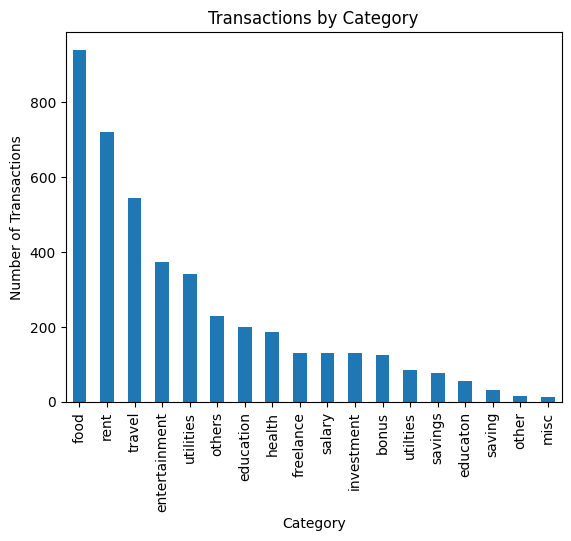

In [111]:
df["category"].value_counts().plot(kind="bar")

plt.title("Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.show()

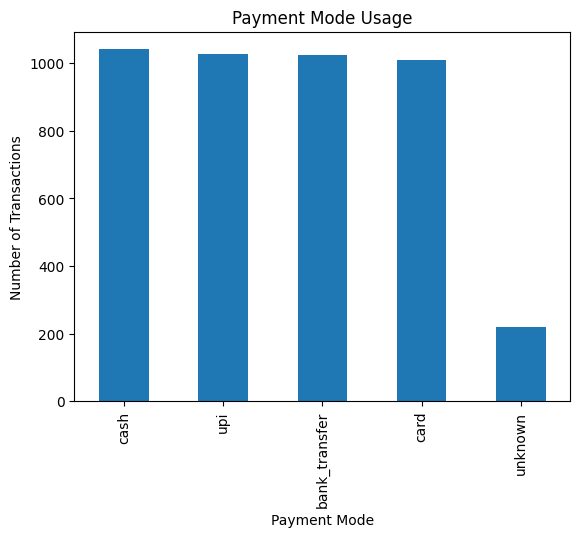

In [112]:
df["payment_mode"].value_counts().plot(kind="bar")

plt.title("Payment Mode Usage")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")

plt.show()

In [120]:
df["category"] = df["category"].str.lower()

In [136]:
df["category"] = df["category"].replace({
    "utilties": "utilities",
    "educaton": "education",
    "educatiealth": "health",
    "saving": "savings",
    "savings": "savings",
    "foodd": "food",
    "misc": "others",
    "others": "others",
    "other": "others"
})

In [137]:
df["category"].value_counts()

,count
category,
food,940
rent,720
travel,543
utilities,426
entertainment,372
education,256
others,255
health,187
freelance,131


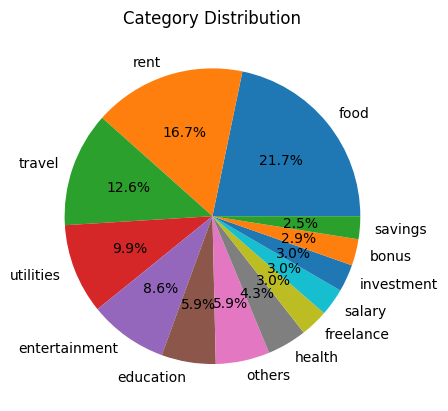

In [138]:
df["category"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Category Distribution")
plt.ylabel("")

plt.show()

In [139]:
df["location"] = df["location"].str.lower()

In [140]:
df["location"] = df["location"].replace({
    "pun": "pune",
    "bangalore": "bengaluru"
})

In [141]:
df["location"] = df["location"].fillna("unknown")

In [142]:
df["location"].value_counts().head(10)

,count
location,
pune,435
unknown,363
delhi,323
kolkata,312
mumbai,305
bengaluru,305
chennai,302
hyderabad,290
ahmedabad,287


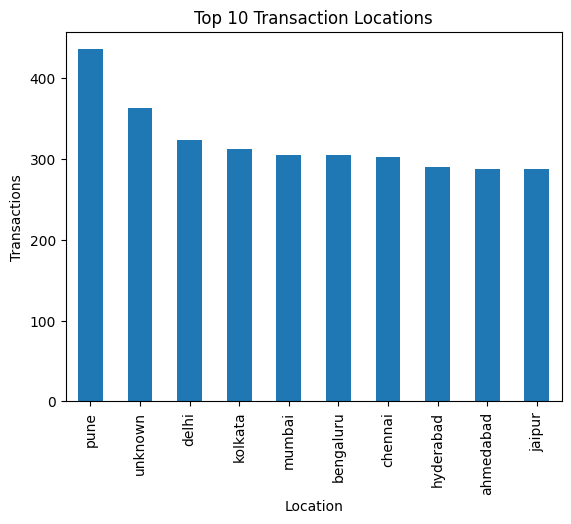

In [143]:
df["location"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Transaction Locations")
plt.xlabel("Location")
plt.ylabel("Transactions")

plt.show()

In [144]:
df["month"] = df["date"].dt.month

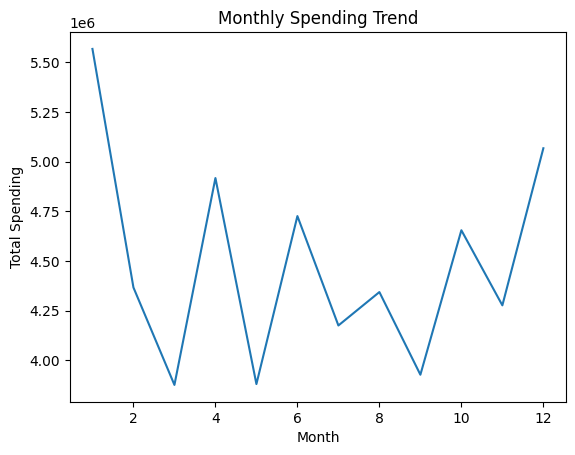

In [145]:
df.groupby("month")["amount"].sum().plot(kind="line")

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")

plt.show()

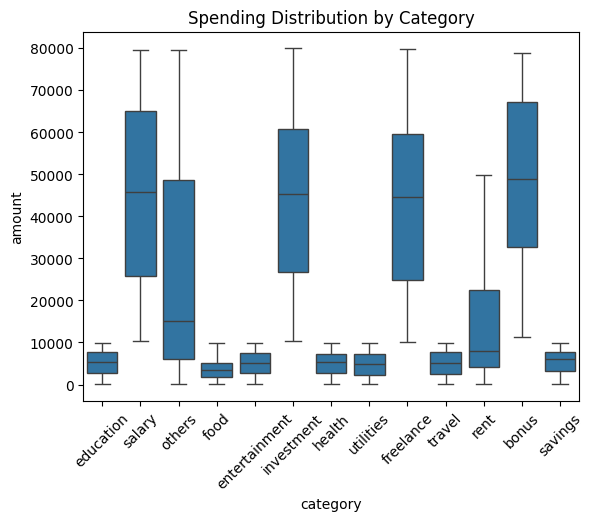

In [146]:
sns.boxplot(x="category", y="amount", data=df)

plt.title("Spending Distribution by Category")
plt.xticks(rotation=45)

plt.show()

In [147]:
df.groupby("category")["amount"].sum().sort_values(ascending=False)

,amount
category,
rent,10260166.0
others,6841523.0
bonus,6024262.0
salary,5964409.0
freelance,5695187.0
investment,5682026.0
food,3643484.0
travel,2782373.0
utilities,2049961.0


In [148]:
df["payment_mode"].value_counts()

,count
payment_mode,
cash,1041
upi,1027
bank_transfer,1025
card,1010
unknown,219


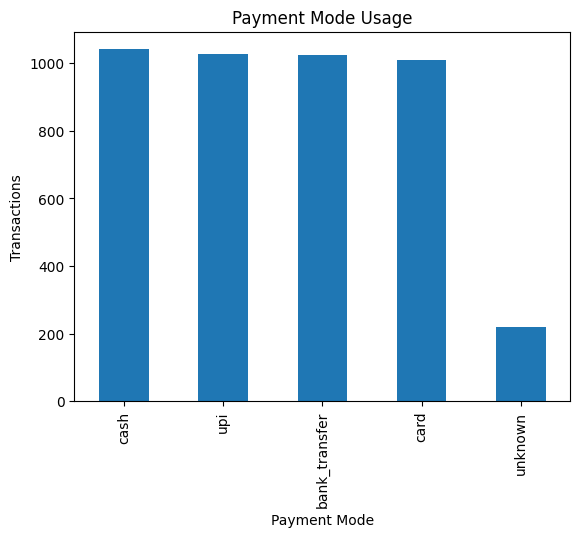

In [149]:
df["payment_mode"].value_counts().plot(kind="bar")

plt.title("Payment Mode Usage")
plt.xlabel("Payment Mode")
plt.ylabel("Transactions")

plt.show()

In [150]:
df["month"] = df["date"].dt.month

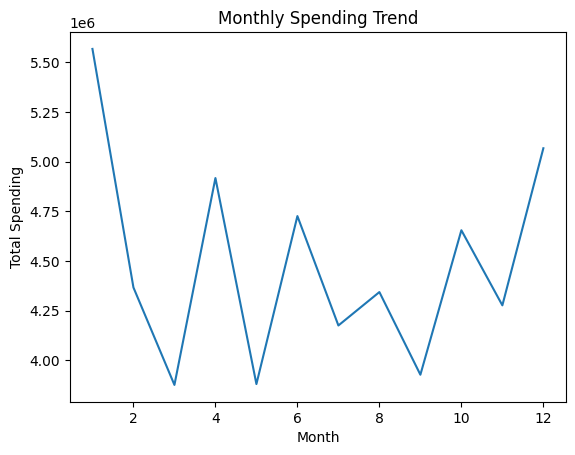

In [151]:
df.groupby("month")["amount"].sum().plot(kind="line")

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")

plt.show()

In [152]:
df.describe()

,date,amount,month
count,4322,4322.000000,4322.000000
mean,2023-01-06 04:12:12.993984512,12442.976631,6.550440
min,2021-01-01 00:00:00,57.000000,1.000000
25%,2022-01-02 00:00:00,2938.250000,4.000000
50%,2023-01-12 00:00:00,5990.500000,7.000000
75%,2024-01-06 18:00:00,9389.750000,10.000000
max,2024-12-31 00:00:00,79950.000000,12.000000
std,NaN,17554.339479,3.491435
